# Introduction Number Theory

Summary:

- Prime Numbers
- Modular Arithmetic
- Discrete Logarithms


In [57]:
from utils import *
%load_ext autoreload
%autoreload 2

print("=" * 70)
print("✓ Environment ready")
print("=" * 70)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Environment ready


## Numeri primi

Brevi richiami:

- Un intero $p > 1$ è un **numero primo** se e solo se i suoi unici divisori sono $1$ e $p$.
- Tutti i numeri diversi da $1$ e dai numeri primi sono **numeri composti**: numeri che sono il prodotto di almeno due numeri primi.
- Ogni intero $a > 1$ può essere scomposto in modo univoco come:
  $a = p_1 \times p_2 \times \cdots \times p_k$,
  dove $p_i$ sono numeri primi.
- Due numeri $a,b$ sono **coprimi** se il loro unico fattore intero positivo comune è $1$.
  $\implies \operatorname{gcd}(a,b) = 1$

L'**Algoritmo di Euclide** ci permette di trovare il $\operatorname{gcd}$ (massimo comun divisore) tra due interi $a$ e $b$, senza dover effettuare alcuna scomposizione in fattori primi.


In [58]:
# Implementazione Algoritmo di Euclide
def gcd(a, b):
    while b != 0:
        a, b = b, a % b
    return a

## Aritmetica modulare

Brevi richiami:

- Due interi $a$ e $b$ sono **congruenti modulo $n$** se la loro differenza è divisibile per $n$:
  $\quad a \equiv b \pmod n
  \iff
  n \mid (a-b)$
- L'insieme dei possibili resti modulo $n$ è:
  $\quad \mathbb{Z}_n = \{0,1,2,\ldots,n-1\}$

Come esempio, consideriamo $\mathbb{Z}_5$:
<div style="display:flex; text-align:center; justify-content: center; gap: 30px;">
  <div style="width: 500px; text-align: center;">
    <img src="imgs/Z5.png" style="width: 500px; height: auto;">
  </div>

</div>


In [59]:
# Implementare una funzione congruenza modulo n 

## Groups

Dato un insieme finito e un'operazione binaria, un **gruppo** $G$ richiede quattro proprietà:

1. **Chiusura**: $a \circ b$ appartiene ancora all'insieme, per ogni $a, b$.
2. **Associatività**: $(a \circ b) \circ c = a \circ (b \circ c)$.
3. **Elemento neutro**: esiste $e$ tale che $e \circ a = a \circ e = a$ per ogni $a$.
4. **Inverso**: per ogni $a$ esiste $a^{-1}$ tale che $a \circ a^{-1} = e$.

Indichiamo come $(G, +)$



In [60]:
#################################################
# Check if (Z5, +) is a group
#################################################
Z5 = [0, 1, 2, 3, 4]
def op(a, b):
    return (a + b) % 5

close = True
ass   = True
neutr = None

# 1. Check the closure 
for a in Z5:
    for b in Z5:
        res = op(a,b)
        if res not in Z5:
            close = False

# 2. Check the association 
for a in Z5:
    for b in Z5:
        for c in Z5:
            if op(op(a,b),c) != op(a,op(b,c)):
                ass = False
                
# 3. Check the existence of the neutral element and find it
for e in Z5:
    elem = True
    for a in Z5:
        if op(e, a) != a or op(a, e) != a:
            elem = False
            break
    if elem:
        neutr = e
        break
print(f"Elemento neutro \n\n e = {neutr}")

# 4. Check the existence of the inverse
inversi_ok = neutr is not None

if neutr is not None:
    for a in Z5:
        trovato_inverso = False
        for b in Z5:
            if op(a, b) == neutr:
                trovato_inverso = True
                inverso_di_a = b
                break
        if not trovato_inverso:
            inversi_ok = False

# 5. Print the Addition Table for Z5
print("\nTabella di addizione di Z5:")
print()

intestazione = "   + "
for b in Z5:
    intestazione += f"{b:3}"
print(intestazione)

print("  " + "----" * len(Z5))

# Righe della tabella: elemento a fianco + risultati
for a in Z5:
    riga = f"{a:3} |"
    for b in Z5:
        riga += f"{op(a, b):3}"
    print(riga)

Elemento neutro 

 e = 0

Tabella di addizione di Z5:

   +   0  1  2  3  4
  --------------------
  0 |  0  1  2  3  4
  1 |  1  2  3  4  0
  2 |  2  3  4  0  1
  3 |  3  4  0  1  2
  4 |  4  0  1  2  3


In [3]:
#################################################
# Check if (Z5, *) is a group
#################################################
Z5 = [ 1, 2, 3, 4, 5, 6]
def op(a, b):
    return (a * b) % 7

close = True
ass   = True
neutr = None

# 1. Check the closure 
for a in Z5:
    for b in Z5:
        res = op(a,b)
        if res not in Z5:
            close = False

# 2. Check the association 
for a in Z5:
    for b in Z5:
        for c in Z5:
            if op(op(a,b),c) != op(a,op(b,c)):
                ass = False
                
# 3. Check the existence of the neutral element and find it
for e in Z5:
    elem = True
    for a in Z5:
        if op(e, a) != a or op(a, e) != a:
            elem = False
            break
    if elem:
        neutr = e
        break
print(f"Elemento neutro \n\n e = {neutr}")
print()
# 4. Check the existence of the inverse
inversi_ok = neutr is not None

if neutr is not None:
    for a in Z5:
        trovato_inverso = False
        for b in Z5:
            if op(a, b) == neutr:
                trovato_inverso = True
                inverso_di_a = b
                break
        if not trovato_inverso:
            inversi_ok = False
            print(f"Elementi senza inverso \n\n {a}")

# 5. Print the Addition Table for Z5
print("\nTabella di moltiplicazione di Z5:")
print()

intestazione = "   * "
for b in Z5:
    intestazione += f"{b:3}"
print(intestazione)

print("  " + "----" * len(Z5))

# Righe della tabella: elemento a fianco + risultati
for a in Z5:
    riga = f"{a:3} |"
    for b in Z5:
        riga += f"{op(a, b):3}"
    print(riga)

print()
print("=" * 70)
print("(Z5,*) non e' un gruppo")
print("=" * 70)

Elemento neutro 

 e = 1


Tabella di moltiplicazione di Z5:

   *   1  2  3  4  5  6
  ------------------------
  1 |  1  2  3  4  5  6
  2 |  2  4  6  1  3  5
  3 |  3  6  2  5  1  4
  4 |  4  1  5  2  6  3
  5 |  5  3  1  6  4  2
  6 |  6  5  4  3  2  1

(Z5,*) non e' un gruppo


## Gruppi in Crittografia

Consideriamo l'insieme degli interi modulo $n$:

$$
\mathbb{Z}_n = \{0,1,2,\ldots,n-1\}
$$

Rispetto alla moltiplicazione modulo $n$, però, $\mathbb{Z}_n$ non è generalmente un gruppo, perché non tutti gli elementi hanno un inverso moltiplicativo.   
Se scegliamo $n$ come **numero primo**, la situazione si semplifica notevolmente. Infatti, se $n$ è primo e $a \in \{1,2,\ldots,n-1\}$, allora $a$ non ha fattori comuni con $n$ diversi da $1$.

$$
\gcd(a,n)=1
\qquad
\forall a \in \{1,2,\ldots,n-1\}
$$

Di conseguenza, tutti gli elementi non nulli di $\mathbb{Z}_n$ hanno un **inverso moltiplicativo modulo $n$**.   
Possiamo quindi considerare il gruppo moltiplicativo:

$$
(\mathbb{Z}_n^*, *)
$$

### Radici Primitive


Un elemento $g \in \mathbb{Z}_n^*$ si dice **generatore** del gruppo se, calcolando le sue potenze modulo $n$, possiamo ottenere tutti gli elementi del gruppo.

$$
\langle g \rangle =
\{g^0,g^1,g^2,\ldots\}
=
\mathbb{Z}_n^*
$$

Un generatore di $\mathbb{Z}_n^*$ viene chiamato **radice primitiva modulo $n$**.  
Se $n$ è primo, $\mathbb{Z}_n^*$ contiene $n-1$ elementi. Pertanto, $g$ è una radice primitiva modulo $n$ se le potenze producono tutti i $n-1$ elementi di $\mathbb{Z}_n^*$ senza ripetizioni.

$$
g^0,g^1,g^2,\ldots,g^{n-2},g^{n-1} \pmod n
$$

Esempio:

| $g$ | $g^0$ | $g^1$ | $g^2$ | $g^3$ | $g^4$ | Elementi generati | Radice primitiva? |
|---:|---:|---:|---:|---:|---:|---|:---:|
| $1$ | $1$ | $1$ | $1$ | $1$ | $1$ | $\{1\}$ | ❌ |
| $2$ | $1$ | $2$ | $4$ | $3$ | $1$ | $\{1,2,3,4\}$ | ✅ |
| $3$ | $1$ | $3$ | $4$ | $2$ | $1$ | $\{1,2,3,4\}$ | ✅ |
| $4$ | $1$ | $4$ | $1$ | $4$ | $1$ | $\{1,4\}$ | ❌ |

Quindi le **radici primitive modulo $5$** sono:$\quad
\boxed{2,3}
$

### Trovare le radici 

Per trovare una radice primitiva modulo un primo $p$, possiamo utilizzare diversi approcci.

#### Brute force

Il metodo più semplice consiste nel provare tutti i possibili candidati $g$ e verificare se le
loro potenze generano tutti gli elementi di $\mathbb{Z}_p^*$.  
Questo approccio è semplice da implementare, ma richiede nel caso peggiore circa $O(p^2)$
operazioni, poiché possiamo dover provare $O(p)$ candidati e, per ciascuno, calcolare fino a
$O(p)$ potenze.


In [62]:
# Starting with this prime
p = 23
g_candidates = []

# Find primitive roots for p
for i in range(1, p):
    generated_elements = []
    for exp in range(1,p):
        value = pow(i,exp,p)
        if not value in generated_elements:
            generated_elements.append(value)
    if(len(generated_elements) == p - 1):
        g_candidates.append(i)

print(f"Primitive roots of p: {g_candidates}")


def primitive_roots_bruteforce(p): 
    g_candidates = [] 
    for i in range(1, p): 
        generated_elements = set() 
        for exp in range(1, p): 
            value = pow(i, exp, p) 
            generated_elements.add(value) 
            if len(generated_elements) == p - 1: 
                break 
    if len(generated_elements) == p - 1: 
        g_candidates.append(i) 
    return g_candidates

Primitive roots of p: [5, 7, 10, 11, 14, 15, 17, 19, 20, 21]


The previous one requires complexity $O(p^2)$, it works well with small values of $p$.  
But when $p$ starts to become high we have some problems


#### Possiamo fare meglio?

Il brute force calcola molte più potenze di quelle realmente necessarie.  
**Fatto chiave**: se $p$ è primo, il gruppo $\mathbb{Z}_p^*$ è ciclico e ha ordine:

$$
n = p-1.
$$

Per il **teorema di Lagrange**, l'ordine di ogni elemento deve dividere $n$.  
Quindi un elemento $g$ ha ordine esattamente $n$ (ed è quindi un generatore) se e solo se:

$$
g^{n/q} \not\equiv 1 \pmod p
$$

per ogni **fattore primo distinto** $q$ di $n$.

Se:

$$
n = q_1^{a_1}q_2^{a_2}\cdots q_k^{a_k},
$$

è sufficiente verificare:

$$
g^{n/q_i} \not\equiv 1 \pmod p
\qquad
\forall i \in \{1,\ldots,k\}.
$$

Invece di calcolare tutte le $n$ potenze, dobbiamo quindi effettuare soltanto $k$ test.

> **Nota pratica: safe prime**
>
> Nella pratica crittografica, può essere utile scegliere $p$ come **safe prime**, cioè $ p = 2q+1 $ dove anche $q$ è primo.
>
> In questo modo conosciamo immediatamente la fattorizzazione di $p-1$
>
> $$ p-1=2q $$
>
> Il test per verificare se $g$ è una radice primitiva richiede quindi soltanto:
>
> $$ g^{(p-1)/2} \not\equiv 1 \pmod p, \quad g^{(p-1)/q} \not\equiv 1 \pmod p$$
>
>
> La scelta di safe prime è quindi utile perché rende particolarmente semplice la gestione della struttura del gruppo $\mathbb{Z}_p^*$.

In [63]:
from sympy import factorint

p = 10037
n = p - 1

# Fattorizzazione di p-1
factors = factorint(n)

print(f"p = {p}")
print(f"p - 1 = {n} = {factors}")

# Cerchiamo una radice primitiva
for g in range(2, p):
    if all(pow(g, n // q, p) != 1 for q in factors):
        print(f"Radice primitiva trovata: g = {g}")
        break

p = 10037
p - 1 = 10036 = {2: 2, 13: 1, 193: 1}
Radice primitiva trovata: g = 2


     p |   Brute force (s) |  Metodo efficiente (s)
---------------------------------------------------
    23 |          0.000059 |               0.000023
   101 |          0.001414 |               0.000009
   503 |          0.066932 |               0.000043
   727 |          0.135001 |               0.000048
  1231 |          0.433223 |               0.000040
  2003 |          1.226023 |               0.000070
  3463 |          4.141605 |               0.000051
  5003 |         12.443614 |               0.000050
  6199 |         20.035569 |               0.000045
 10007 |         49.761798 |               0.000075


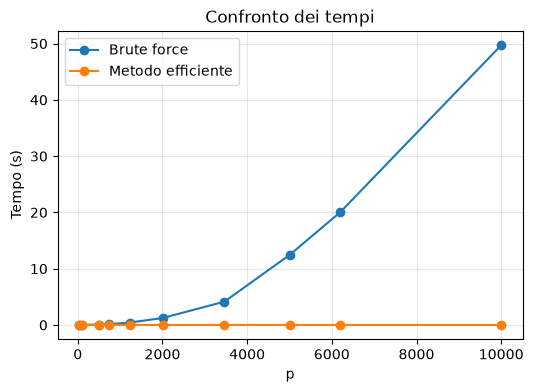

In [65]:
test_primes = [23, 101, 503, 727, 1231, 2003, 3463, 5003, 6199, 10007]
compare_primitive_roots(test_primes)

---

Exploiting the fact that:

$$\operatorname{gcd}(a,b) = \operatorname{gcd(b, a mod b)} \quad \forall a,b \in \mathbb{Z} \quad a \geq b \geq 0.$$

The algorithm can be seen as an iterative function:

```
FUNCTION GCD(a,b):
    if (b = 0) then return a;
    else return GCD(b, a mod b); 
```
<br>

### Extended Euclidean Algorithm

An extension of the previous algorithm to find **modular inverse** of a number.    
Brief recall about the **Bézout's Identity**:

> Let $a$ and $b$ be integers with greatest common divisor $\operatorname{gcd}(a,b) = d$. Then there exist integers $x$ and $y$ such that
> $$ax + by = d$$

If we work in a group $(\mathbb{Z}_p, *)$ we can exploit this identity to find multiplicative inverse of any number $a \in [0,p-1]$.  
In fact:

- $a$ and $p$ are coprime we know that $\operatorname{gcd}(a,b) = 1$.
- $(\mathbb{Z}_p, *)$ is a group so a multiplicative inverse exsists.
- The coefficent $x$ will provide the multiplicative inverse of $a$.


<div style="display:flex; text-align:center; justify-content: center; gap: 30px;">
  <div style="width: 500px; text-align: center;">
    <img src="imgs/extended euclidean.png" style="width: 500px; height: auto;">
  </div>

</div>


In [13]:
# Implement the Extended Euclidean Algorithm to find the multiplicative inverse

def inverso_moltiplicativo_iterativo(a, p):
    old_r, r = a, p
    old_x, x = 1, 0
    # old_y, y = 0, 1

    while r != 0:
        q = old_r // r
        old_r, r = r, old_r - q * r
        old_x, x = x, old_x - q * x
        #old_y, y = y, old_y - q * y

    if old_r != 1:
        raise ValueError(f"L'inverso non esiste: gcd({a}, {p}) = {old_r} != 1")

    return old_x % p


# Esempio d'uso
a = 7
p = 10037

inv_we = inverso_moltiplicativo_iterativo(a, p)
print(f"L'inverso di {a} mod {p} è {inv_we}")

L'inverso di 7 mod 10037 è 1434


# Computationally Hard Problems

DLP and IFP


## Discrete Logarithm Problem (DLP)

Given $(g, g^x)$ find $x$ 


Quanto costa un attacco dato che $p$ e' un numero di $n$ bit allora $2^{n-1} \leq p \leq 2^{n}$ 

$p \approx 2^n$ di conseguenza $∣G∣=p−1$ ovvero $G \approx 2^n$  

Per trovare $x$ dobbiamo provare tutti gli esponenti fino a trovare il valore giusto 

$$g^0, g^1, g^2, \cdots$$



Questo e' l'attacco brute force ma ci sta uno migliore che e' il big step small step 




, la funzione x → αˣ mod p si comporta come una permutazione pseudocasuale dell'insieme {1, ..., p−1} (assumendo α generatore, cioè che il suo ordine sia p−1). Non c'è una struttura "liscia" da invertire analiticamente: conoscendo β non hai un modo diretto per risalire a x, devi affidarti ad algoritmi generici (ricerca esaustiva, baby-step giant-step, Pollard's rho, o per campi finiti classici il metodo dell'index calculus).

In [66]:
"""
Visualizzazione del problema del logaritmo discreto (DLP).

Confronta la crescita "pura" di alpha^x con la sequenza alpha^x mod p,
per mostrare perché invertire la seconda (trovare x dato beta) e' difficile.

Include slider interattivi (ipywidgets) per cambiare alpha, p e x_max
a runtime in un notebook Jupyter, senza dover rieseguire la cella a mano.
"""

import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# -----------------------------------------------------------------------
# PARAMETRI (modifica questi per l'esercitazione)
# -----------------------------------------------------------------------
ALPHA = 2              # base / generatore
P = 8589935681         # modulo (deve essere primo per un vero gruppo DLP)
X_MAX = 600             # numero di esponenti da calcolare (x = 0 .. X_MAX-1)

# -----------------------------------------------------------------------
# CALCOLO DELLE SEQUENZE
# -----------------------------------------------------------------------
def compute_sequences(alpha, p, x_max):
    """Restituisce (x_values, beta_pure, beta_mod).

    beta_pure contiene alpha**x solo finche' resta <= p (oltre non serve
    disegnarlo, esplode subito fuori scala); beta_mod contiene alpha**x mod p
    per ogni x, calcolato in modo efficiente con pow(alpha, x, p).
    """
    x_values = list(range(x_max))

    beta_mod = [pow(alpha, x, p) for x in x_values]

    beta_pure_x, beta_pure_y = [], []
    value = 1
    for x in x_values:
        if value > p:
            break
        beta_pure_x.append(x)
        beta_pure_y.append(value)
        value *= alpha

    return x_values, (beta_pure_x, beta_pure_y), beta_mod


def plot_dlp(alpha, p, x_max):
    x_values, (pure_x, pure_y), mod_y = compute_sequences(alpha, p, x_max)

    fig, ax = plt.subplots(figsize=(5, 4))

    # Linea blu: crescita esponenziale pura (senza modulo)
    ax.plot(pure_x, pure_y, color="tab:blue", linewidth=1,
            label=r"$\beta = \alpha^{x}$")

    # Punti rossi: sequenza modulare (quella "difficile" da invertire)
    ax.scatter(x_values, mod_y, color="red", marker="*", s=25,
               label=r"$\beta = \alpha^{x}$ mod $p$")

    ax.set_yscale("log")
    ax.set_xlim(0, x_max)
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(rf"$\alpha$ = {alpha}, p = {p}")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    ax.legend(loc="lower right")

    fig.tight_layout()
    plt.show()  # in Jupyter mostra il grafico inline nella cella (con %matplotlib inline)


# -----------------------------------------------------------------------
# SLIDER INTERATTIVI (Jupyter)
# -----------------------------------------------------------------------
# Eseguendo questa cella in un notebook Jupyter compaiono 3 slider
# (alpha, p, x_max) e il grafico si ridisegna automaticamente ad ogni
# modifica. Nota: p viene forzato a un numero dispari per restare
# ragionevolmente vicino a un modulo "tipo primo" nei range piccoli;
# per un vero esercizio di crittografia scegli p effettivamente primo.
interact(
    plot_dlp,
    alpha=IntSlider(min=2, max=20, step=1, value=ALPHA, description="alpha"),
    p=IntSlider(min=11, max=200000, step=2, value=P if P < 200000 else 104729,
                description="p"),
    x_max=IntSlider(min=10, max=1000, step=10, value=X_MAX, description="x_max"),
)

interactive(children=(IntSlider(value=2, description='alpha', max=20, min=2), IntSlider(value=104729, descript…

<function __main__.plot_dlp(alpha, p, x_max)>

Come possiamo vedere fissando il valore di B abbiamo diversi valori di esponenti che ci danno lo stesso beta